In [3]:
import os
import numpy as np

image_dataset_path = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/Dataset/'
output_filename = 'preprocessed_image_dataset.npz'
full_output_path = os.path.join(image_dataset_path, output_filename)

loaded_data = np.load(full_output_path)
loaded_images = loaded_data['images']
loaded_labels = loaded_data['labels']

print(f"Verified: Loaded images shape: {loaded_images.shape}, Loaded labels shape: {loaded_labels.shape}")

Verified: Loaded images shape: (2767, 128, 128, 3), Loaded labels shape: (2767,)


In [4]:
import numpy as np

unique_labels, counts = np.unique(loaded_labels, return_counts=True)

print("Class Labels and Image Counts:")
for label, count in zip(unique_labels, counts):
    print(f"- {label}: {count} images")

Class Labels and Image Counts:
- Hariana Front: 873 images
- Hariana Left: 303 images
- Red_Sindhi Front: 214 images
- Red_Sindhi Left: 148 images
- Sahiwal Front: 268 images
- Sahiwal Left: 218 images
- Tharparkar Left: 272 images
- Tharparker Front: 471 images


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(loaded_labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(loaded_images, encoded_labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2213, 128, 128, 3)
X_test shape: (554, 128, 128, 3)
y_train shape: (2213,)
y_test shape: (554,)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import numpy as np

# Determine the number of unique classes
num_classes = len(np.unique(encoded_labels))

# Define input shape
input_shape = X_train.shape[1:]

# Instantiate a Sequential model
model = Sequential([
    Input(shape=input_shape), # Use Input layer explicitly as the first layer
    Conv2D(32, (3, 3), activation='relu'), # input_shape is no longer needed here
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'), # A common choice for a hidden dense layer
    Dense(num_classes, activation='softmax')
])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,376 (14.14 MB)

 Trainable params: 3,706,376 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

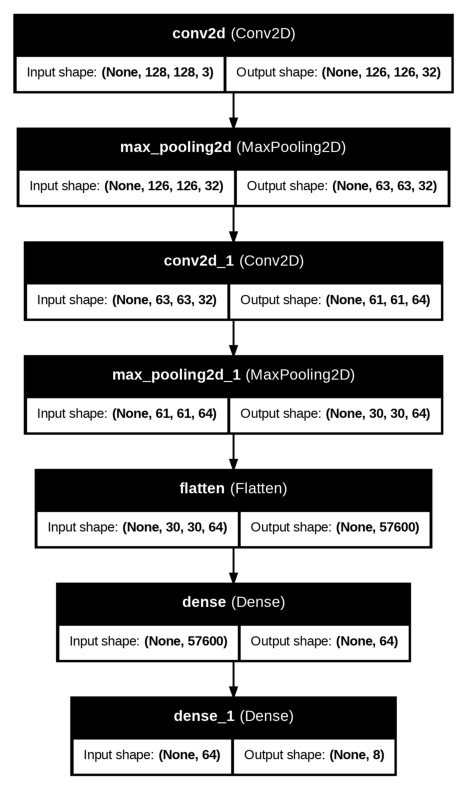

In [7]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

# Save the model plot to a file
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the image in the notebook
img = plt.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()

In [ ]:
import tensorflow as tf

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=10,
                    validation_data=(X_test, y_test))

print("Model training complete.")

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 563ms/step - accuracy: 0.5901 - loss: 1.1547 - val_accuracy: 0.8700 - val_loss: 0.4060
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 593ms/step - accuracy: 0.9272 - loss: 0.2543 - val_accuracy: 0.9332 - val_loss: 0.2439
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 537ms/step - accuracy: 0.9584 - loss: 0.1490 - val_accuracy: 0.9260 - val_loss: 0.2140
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 541ms/step - accuracy: 0.9792 - loss: 0.0743 - val_accuracy: 0.9386 - val_loss: 0.1909
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 541ms/step - accuracy: 0.9887 - loss: 0.0466 - val_accuracy: 0.9458 - val_loss: 0.2043
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 538ms/step - accuracy: 0.9905 - loss: 0.0394 - val_accuracy: 0.9404 - val_loss: 0.2257
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 535ms/step - accuracy: 0.9873 - loss: 0.0467 - val_accuracy: 0.9458 - val_loss: 0.1756
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 529ms/step - accuracy: 0.9941 - loss: 0.0283 - val_accu

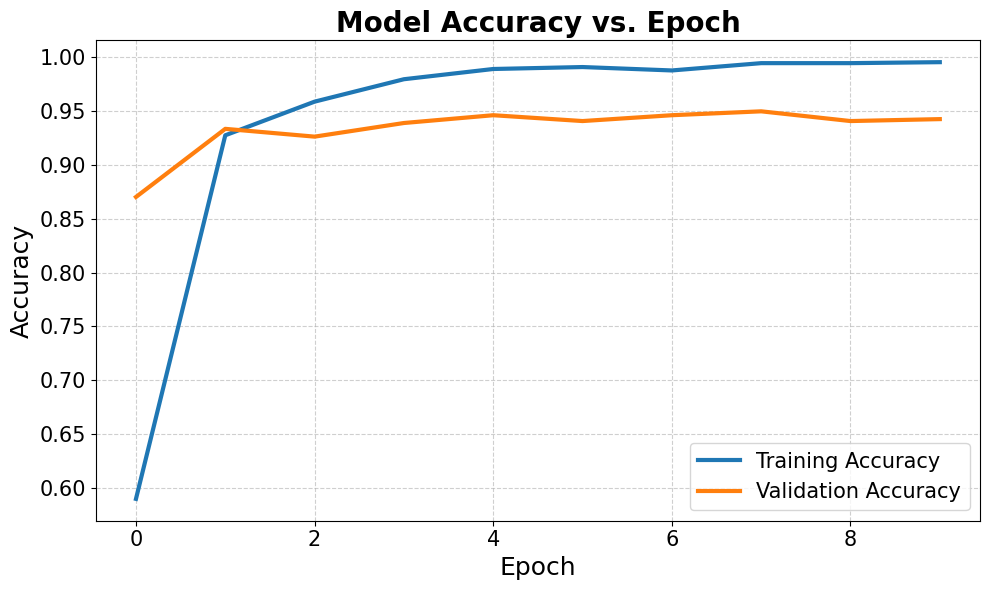

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], linewidth=3)
plt.plot(history.history['val_accuracy'], linewidth=3)

plt.title('Model Accuracy vs. Epoch', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Predict probabilities for the test set
y_pred_probabilities = model.predict(X_test)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9422
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step

Classification Report:
                  precision    recall  f1-score   support

   Hariana Front       0.91      0.97      0.94       180
    Hariana Left       0.89      0.76      0.82        55
Red_Sindhi Front       1.00      0.87      0.93        54
 Red_Sindhi Left       0.97      1.00      0.98        29
   Sahiwal Front       0.93      1.00      0.96        41
    Sahiwal Left       1.00      1.00      1.00        36
 Tharparkar Left       0.96      0.98      0.97        54
Tharparker Front       0.97      0.95      0.96       105

        accuracy                           0.94       554
       macro avg       0.95      0.94      0.95       554
    weighted avg       0.94      0.94      0.94       554


Confusion Matrix:
[[174   5   0   0   0   0   0   1]
 [ 12  42   0   0   0   0   0   1]
 [  3   0  47   1   3   0   0   0]
 [  0   0   0  29   0   0   0   0]
 [  0   0   0   0  41   0   0   0]
 [  0   0   0   0   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


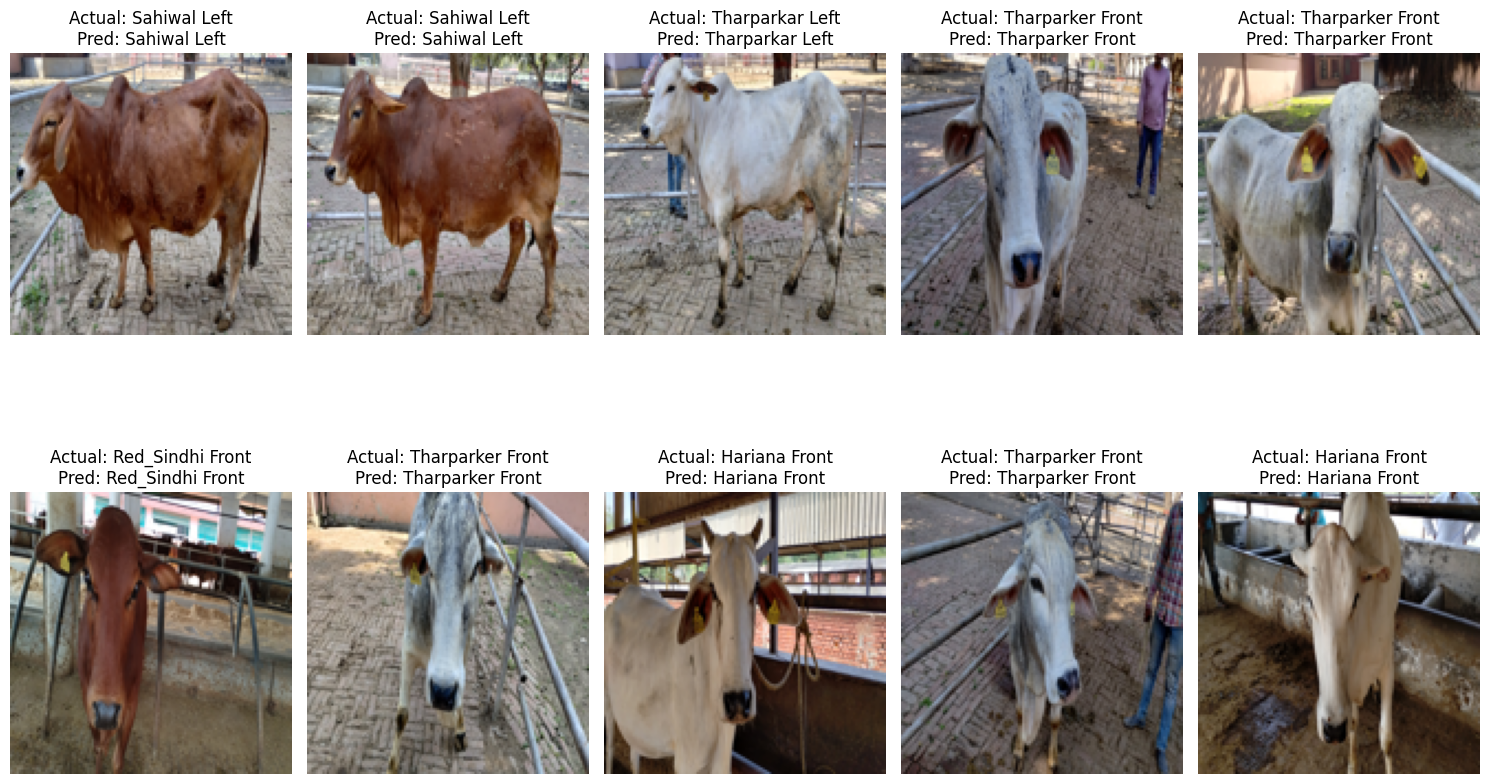

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Randomly select 10 indices from the test dataset
num_samples_to_show = 10
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

# Get the selected images and their true labels
sampled_images = X_test[random_indices]
sampled_true_labels = y_test[random_indices]

# Make predictions for the sampled images
sampled_predictions_probabilities = model.predict(sampled_images)
sampled_predicted_labels = np.argmax(sampled_predictions_probabilities, axis=1)

# Inverse transform numerical labels back to original class names
sampled_true_class_names = label_encoder.inverse_transform(sampled_true_labels)
sampled_predicted_class_names = label_encoder.inverse_transform(sampled_predicted_labels)

# Plot the images with their actual and predicted labels
plt.figure(figsize=(15, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1) # Arrange plots in 2 rows, 5 columns
    #plt.imshow(sampled_images[i].astype('uint8')) # Display image
    plt.imshow(sampled_images[i])# Display image
    plt.title(f"Actual: {sampled_true_class_names[i]}\nPred: {sampled_predicted_class_names[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

# Define the filename for saving the model using the new Keras format
model_filename = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/cnn_classifier_model.keras'

# Save the model
#model.save(model_filename)
print(f"Model saved successfully to '{model_filename}'")

# Load the model back from the file
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded successfully from '{model_filename}'")

# Verify the loaded model by printing its summary
print("\nSummary of the loaded model:")
loaded_model.summary()

Model saved successfully to '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/cnn_classifier_model.keras'
Model loaded successfully from '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/cnn_classifier_model.keras'

Summary of the loaded model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,119,130 (42.42 MB)

 Trainable params: 3,706,376 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,412,754 (28.28 MB)

In [13]:
unseen_dataset_path = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/Unseen dataset code/unseen dataset 2/preprocessed_image_unseen_dataset.npz'

In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the unseen dataset
unseen_data = np.load(unseen_dataset_path)
unseen_images = unseen_data['images']
unseen_labels = unseen_data['labels']

print(f"Loaded unseen images shape: {unseen_images.shape}")
print(f"Loaded unseen labels shape: {unseen_labels.shape}")

# Correct potential label typos in unseen_labels to match the label_encoder classes
# Replace 'Tharparker Left' (with 'e') with 'Tharparkar Left' (with 'a')
unseen_labels_corrected = unseen_labels

# Encode the unseen labels using the *same* label_encoder fitted on the training data
encoded_unseen_labels = label_encoder.transform(unseen_labels_corrected)

# Make predictions on the unseen dataset
unseen_predictions_probabilities = model.predict(unseen_images)
unseen_predicted_labels = np.argmax(unseen_predictions_probabilities, axis=1)

# Calculate accuracy
unseen_accuracy = accuracy_score(encoded_unseen_labels, unseen_predicted_labels)
print(f"\nAccuracy on unseen dataset: {unseen_accuracy:.4f}")

# Print classification report
print("\nClassification Report on Unseen Dataset:")
# Pass the 'labels' parameter to classification_report to ensure all classes are accounted for
print(classification_report(encoded_unseen_labels, unseen_predicted_labels, labels=np.arange(len(label_encoder.classes_)), target_names=label_encoder.classes_))

# Print confusion matrix
print("\nConfusion Matrix on Unseen Dataset:")
# Pass the 'labels' parameter to confusion_matrix as well for consistent output
print(confusion_matrix(encoded_unseen_labels, unseen_predicted_labels, labels=np.arange(len(label_encoder.classes_))))


Loaded unseen images shape: (12, 128, 128, 3)
Loaded unseen labels shape: (12,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step

Accuracy on unseen dataset: 0.1667

Classification Report on Unseen Dataset:
                  precision    recall  f1-score   support

   Hariana Front       0.00      0.00      0.00         2
    Hariana Left       0.00      0.00      0.00         2
Red_Sindhi Front       0.00      0.00      0.00         0
 Red_Sindhi Left       0.00      0.00      0.00         0
   Sahiwal Front       0.50      1.00      0.67         2
    Sahiwal Left       0.00      0.00      0.00         2
 Tharparkar Left       0.00      0.00      0.00         2
Tharparker Front       0.00      0.00      0.00         2

        accuracy                           0.17        12
       macro avg       0.06      0.12      0.08        12
    weighted avg       0.08      0.17      0.11        12


Confusion Matrix on Unseen Dataset:
[[0 0 2 0 0 0 0 0]
 [0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me